# IggyTop DB TCR anaylsis 

In [1]:
import muon as mu
import scanpy as sc
import scirpy as ir

# temporary fix for deprecated matplotlib functionality
import IPython.display
from matplotlib_inline.backend_inline import set_matplotlib_formats

IPython.display.set_matplotlib_formats = set_matplotlib_formats

sc.set_figure_params(figsize=(4, 4))
sc.settings.verbosity = 2  # verbosity: errors (0), warnings (1), info (2), hints (3)

/home/kvalem/.conda/envs/iggytop_env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/kvalem/.conda/envs/iggytop_env/lib/python3.12/site-packages/muon/_core/preproc.py:31: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  if Version(scanpy.__version__) < Version("1.10"):


In [2]:
import numpy as np

In [3]:
sc.logging.print_header()

/tmp/ipykernel_2039774/1023403583.py:1: RuntimeWarning: Failed to import dependencies for application/vnd.jupyter.widget-view+json representation. (ModuleNotFoundError: No module named 'ipywidgets')
  sc.logging.print_header()


Package,Version
ipykernel,7.2.0
muon,0.1.7
scanpy,1.12.1
scirpy,0.24.0
matplotlib-inline,0.2.2
numpy,2.4.6
Component,Info
Python,"3.12.13 | packaged by conda-forge | (main, Mar 5 2026, 16:50:00) [GCC 14.3.0]"
OS,Linux-5.14.0-687.10.1.el9_8.0.1.x86_64-x86_64-with-glibc2.34
CPU,"144/144 logical CPU cores, x86_64"


## 1. Load data

In [4]:
mdata = mu.read_h5mu("/data/projects/2021/MicrobialMetabolites/single-cell-sorted-cd8/results/40_gex_surface_prot/002_annotate_mudata.h5mu")

/home/kvalem/.conda/envs/iggytop_env/lib/python3.12/site-packages/anndata/utils.py:362: ExperimentalFeatureWarning: Support for Awkward Arrays is currently experimental. Behavior may change in the future. Please report any issues you may encounter!
  warnings.warn(msg, category, stacklevel=stacklevel)
/home/kvalem/.conda/envs/iggytop_env/lib/python3.12/site-packages/mudata/_core/mudata.py:1416: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
/home/kvalem/.conda/envs/iggytop_env/lib/python3.12/site-packages/mudata/_core/mudata.py:1272: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False

In [5]:
rename_dict = {
    "10mix_ICI1": "ctrl1",
    "10mix_ICI2": "ctrl2",
    "11mix_ICI1": "effector1",
    "11mix_ICI2": "effector2",
    "GF_ICI1": "GF_noICI1",
    "GF_ICI2": "GF_noICI2",
    "GF_ICI1_plus": "GF1",
    "GF_ICI2_plus": "GF2"
}

mdata["gex"].obs["sample_id"] = (
    mdata["gex"].obs["sample_id"]
    .replace(rename_dict)
)

/tmp/ipykernel_2039774/2648257632.py:14: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  .replace(rename_dict)


In [6]:
mdata["airr"].obs["sample_id"] = (
    mdata["gex"].obs["sample_id"]
    .replace(rename_dict)
)

In [7]:
mdata["airr"].obs["sample_id"]

10mix-ICI1_AAACCTGAGAGCCTAG-1        ctrl1
10mix-ICI1_AAACCTGAGGCTCTTA-1        ctrl1
10mix-ICI1_AAACCTGAGGGCACTA-1        ctrl1
10mix-ICI1_AAACCTGAGGGCTTGA-1        ctrl1
10mix-ICI1_AAACCTGAGGTTACCT-1        ctrl1
                                   ...    
GF-ICI2_TTTGTCAGTTACGCGC-1       GF_noICI2
GF-ICI2_TTTGTCATCACGAAGG-1       GF_noICI2
GF-ICI2_TTTGTCATCATCGGAT-1       GF_noICI2
GF-ICI2_TTTGTCATCGGCGCTA-1       GF_noICI2
GF-ICI2_TTTGTCATCGTATCAG-1       GF_noICI2
Name: sample_id, Length: 56305, dtype: category
Categories (8, object): ['ctrl1', 'ctrl2', 'effector1', 'effector2', 'GF_noICI1', 'GF1', 'GF_noICI2', 'GF2']

In [8]:
mdata["airr"].obs["group4"] =    mdata["gex"].obs["group4"] 

In [9]:
mdata

MuData object with n_obs × n_vars = 72592 × 17590
  3 modalities
    gex:	72592 × 17581
      obs:	'adata_name', 'condition', 'batch_id', 'sample_id', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mito', 'log1p_total_counts_mito', 'pct_counts_mito', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'rna_leiden', 'rna_leiden_05', 'gex03', 'group4', 'cell_annotation_05'
      var:	'gene_ids', 'feature_types', 'mito', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection', 'n_cells'
      uns:	'cell_annotation_05_colors', 'gex03', 'gex03_colors', 'group4_colors', 'hvg', 'log1p', 'neighbors', 'pca', 'rna_leiden', 'rna_leiden_05', 'rna_leiden_05_colors', 'rna_leiden_colors', 'sample_id_colors', 'umap'
      obsm:	'X_pca', 'X_umap'
      varm:	'PCs'
      layers:	'counts'
      obsp:	'connectivities', 'distances'
    adt:	56305 × 9
      obs:	'sample_id', 'year', 'tissue', 'treatment', 'received_ici'
    airr:	56305 × 0
      obs:	'sample_id', 'group4'
      obsm:	'airr'

## 2. Creating chain indices & TCR QC

In [10]:
ir.pp.index_chains(mdata)
ir.tl.chain_qc(mdata)

Filtering chains...
Indexing VJ chains...
Indexing VDJ chains...
build result array
Stored result in `mdata.obs["airr:receptor_type"]`.
Stored result in `mdata.obs["airr:receptor_subtype"]`.
Stored result in `mdata.obs["airr:chain_pairing"]`.


In [11]:
mu.pp.filter_obs(mdata, "airr:chain_pairing", lambda x: ~np.isin(x, ["orphan VDJ", "orphan VJ"]))

In [12]:
# cells in AIRR that are TCR
tcr_cells = mdata["airr"].obs_names[
    mdata["airr"].obs["receptor_type"] == "TCR"
]

# keep only those cells in the full MuData object
mdata = mdata[tcr_cells, :].copy()

/home/kvalem/.conda/envs/iggytop_env/lib/python3.12/site-packages/mudata/_core/mudata.py:1416: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
/home/kvalem/.conda/envs/iggytop_env/lib/python3.12/site-packages/mudata/_core/mudata.py:1272: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("obs", axis=1, join_common=join_common)


In [13]:
mdata.update()

/home/kvalem/.conda/envs/iggytop_env/lib/python3.12/site-packages/mudata/_core/mudata.py:1416: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
/home/kvalem/.conda/envs/iggytop_env/lib/python3.12/site-packages/mudata/_core/mudata.py:1272: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("obs", axis=1, join_common=join_common)


In [14]:
mdata

MuData object with n_obs × n_vars = 48227 × 17590
  3 modalities
    gex:	48227 × 17581
      obs:	'adata_name', 'condition', 'batch_id', 'sample_id', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mito', 'log1p_total_counts_mito', 'pct_counts_mito', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'rna_leiden', 'rna_leiden_05', 'gex03', 'group4', 'cell_annotation_05'
      var:	'gene_ids', 'feature_types', 'mito', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection', 'n_cells'
      uns:	'cell_annotation_05_colors', 'gex03', 'gex03_colors', 'group4_colors', 'hvg', 'log1p', 'neighbors', 'pca', 'rna_leiden', 'rna_leiden_05', 'rna_leiden_05_colors', 'rna_leiden_colors', 'sample_id_colors', 'umap'
      obsm:	'X_pca', 'X_umap'
      varm:	'PCs'
      layers:	'counts'
      obsp:	'connectivities', 'distances'
    adt:	48227 × 9
      obs:	'sample_id', 'year', 'tissue', 'treatment', 'received_ici'
    airr:	48227 × 0
      obs:	'sample_id', 'group4', 'receptor_type', 'receptor_subtype', 'chain_pairing'
      uns:	'chain_indices'
      obsm:	'airr', 'chain_indices'

## 3. Define clonotypes and clonotype clusters

In [15]:
ir.pp.ir_dist(mdata)
ir.tl.define_clonotypes(mdata, receptor_arms="all", dual_ir="primary_only")

Computing sequence x sequence distance matrix for VJ sequences.
Computing sequence x sequence distance matrix for VDJ sequences.
Initializing lookup tables. 
Computing clonotype x clonotype distances.
Stored result in `mdata.obs["airr:clone_id"]`.
Stored result in `mdata.obs["airr:clone_id_size"]`.


In [16]:
ir.tl.clonotype_network(mdata, min_cells=500)

## 4. Top clones

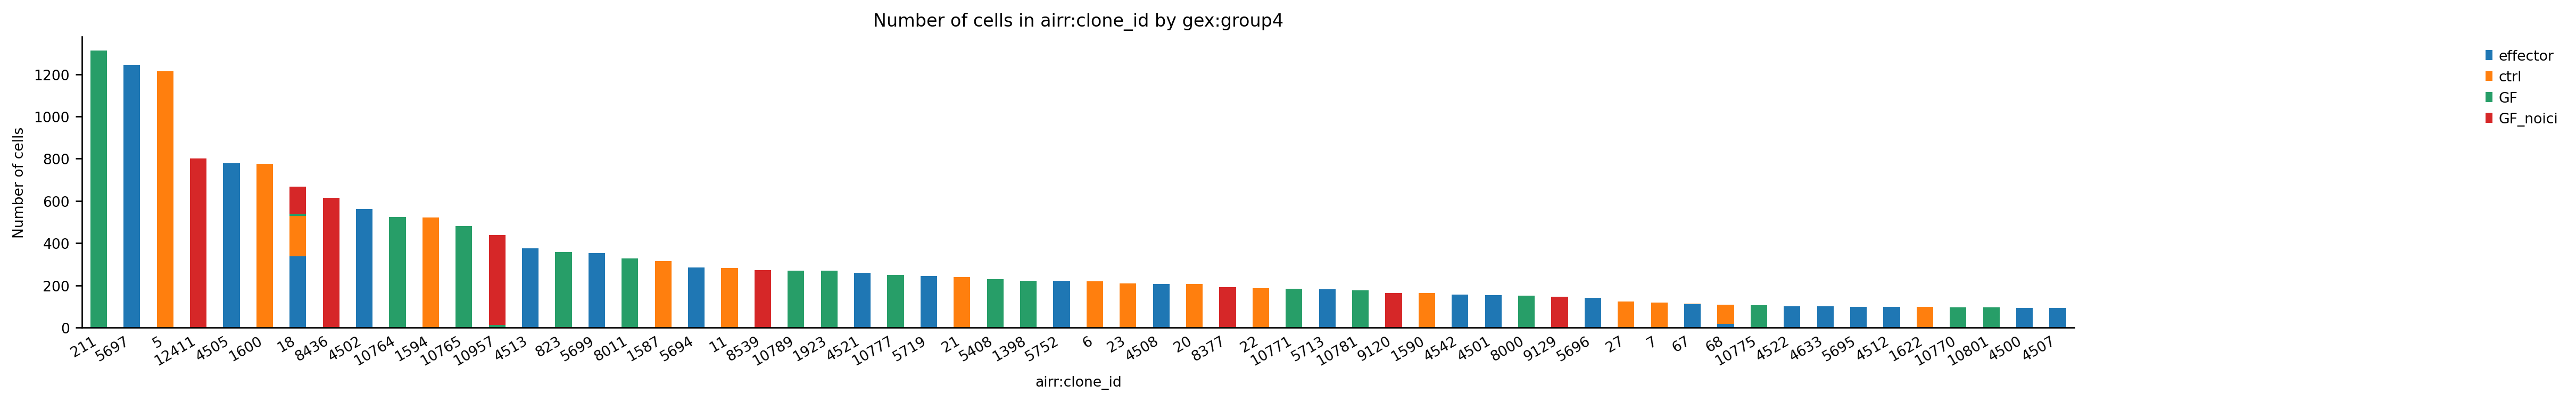

In [17]:
_ = ir.pl.group_abundance(mdata, groupby="airr:clone_id", target_col="gex:group4", max_cols=60, figsize=(20, 3))

### Top clonotypes filtered by threshold  > 100 cells 

In [18]:
import pandas as pd

clone_sizes = (
    mdata.obs["airr:clone_id"]
    .value_counts()
    .rename_axis("clone_id")
    .reset_index(name="n_cells")
)

In [19]:
large_clones = clone_sizes.loc[clone_sizes["n_cells"] > 300]

In [20]:
abundance_df = pd.crosstab(
    mdata.obs["airr:clone_id"],
    mdata.obs["gex:group4"]
)

In [21]:
clone_counts = abundance_df.sum(axis=1)

abundance_df_filtered = abundance_df.loc[clone_counts > 300]

In [22]:
top_clone_ids = abundance_df_filtered.index.to_list()

In [23]:
top_clone_ids

['5',
 '18',
 '211',
 '823',
 '1587',
 '1594',
 '1600',
 '4502',
 '4505',
 '4513',
 '5697',
 '5699',
 '8011',
 '8436',
 '10764',
 '10765',
 '10957',
 '12411']

In [24]:
import scanpy as sc

keep_clones = abundance_df_filtered.index

mdata_large = mdata[
    mdata.obs["airr:clone_id"].isin(keep_clones)
].copy()

/home/kvalem/.conda/envs/iggytop_env/lib/python3.12/site-packages/mudata/_core/mudata.py:1416: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
/home/kvalem/.conda/envs/iggytop_env/lib/python3.12/site-packages/mudata/_core/mudata.py:1272: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("obs", axis=1, join_common=join_common)


In [25]:
mdata_large

MuData object with n_obs × n_vars = 11664 × 17590
  3 modalities
    gex:	11664 × 17581
      obs:	'adata_name', 'condition', 'batch_id', 'sample_id', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mito', 'log1p_total_counts_mito', 'pct_counts_mito', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'rna_leiden', 'rna_leiden_05', 'gex03', 'group4', 'cell_annotation_05'
      var:	'gene_ids', 'feature_types', 'mito', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection', 'n_cells'
      uns:	'cell_annotation_05_colors', 'gex03', 'gex03_colors', 'group4_colors', 'hvg', 'log1p', 'neighbors', 'pca', 'rna_leiden', 'rna_leiden_05', 'rna_leiden_05_colors', 'rna_leiden_colors', 'sample_id_colors', 'umap'
      obsm:	'X_pca', 'X_umap'
      varm:	'PCs'
      layers:	'counts'
      obsp:	'connectivities', 'distances'
    adt:	11664 × 9
      obs:	'sample_id', 'year', 'tissue', 'treatment', 'received_ici'
    airr:	11664 × 0
      obs:	'sample_id', 'group4', 'receptor_type', 'receptor_subtype', 'chain_pairing', 'clone_id', 'clone_id_size'
      uns:	'chain_indices', 'ir_dist_nt_identity', 'clone_id', 'clonotype_network'
      obsm:	'airr', 'chain_indices', 'X_clonotype_network'

<Axes: title={'center': 'Number of cells in airr:clone_id by gex:group4'}, xlabel='airr:clone_id', ylabel='Number of cells'>

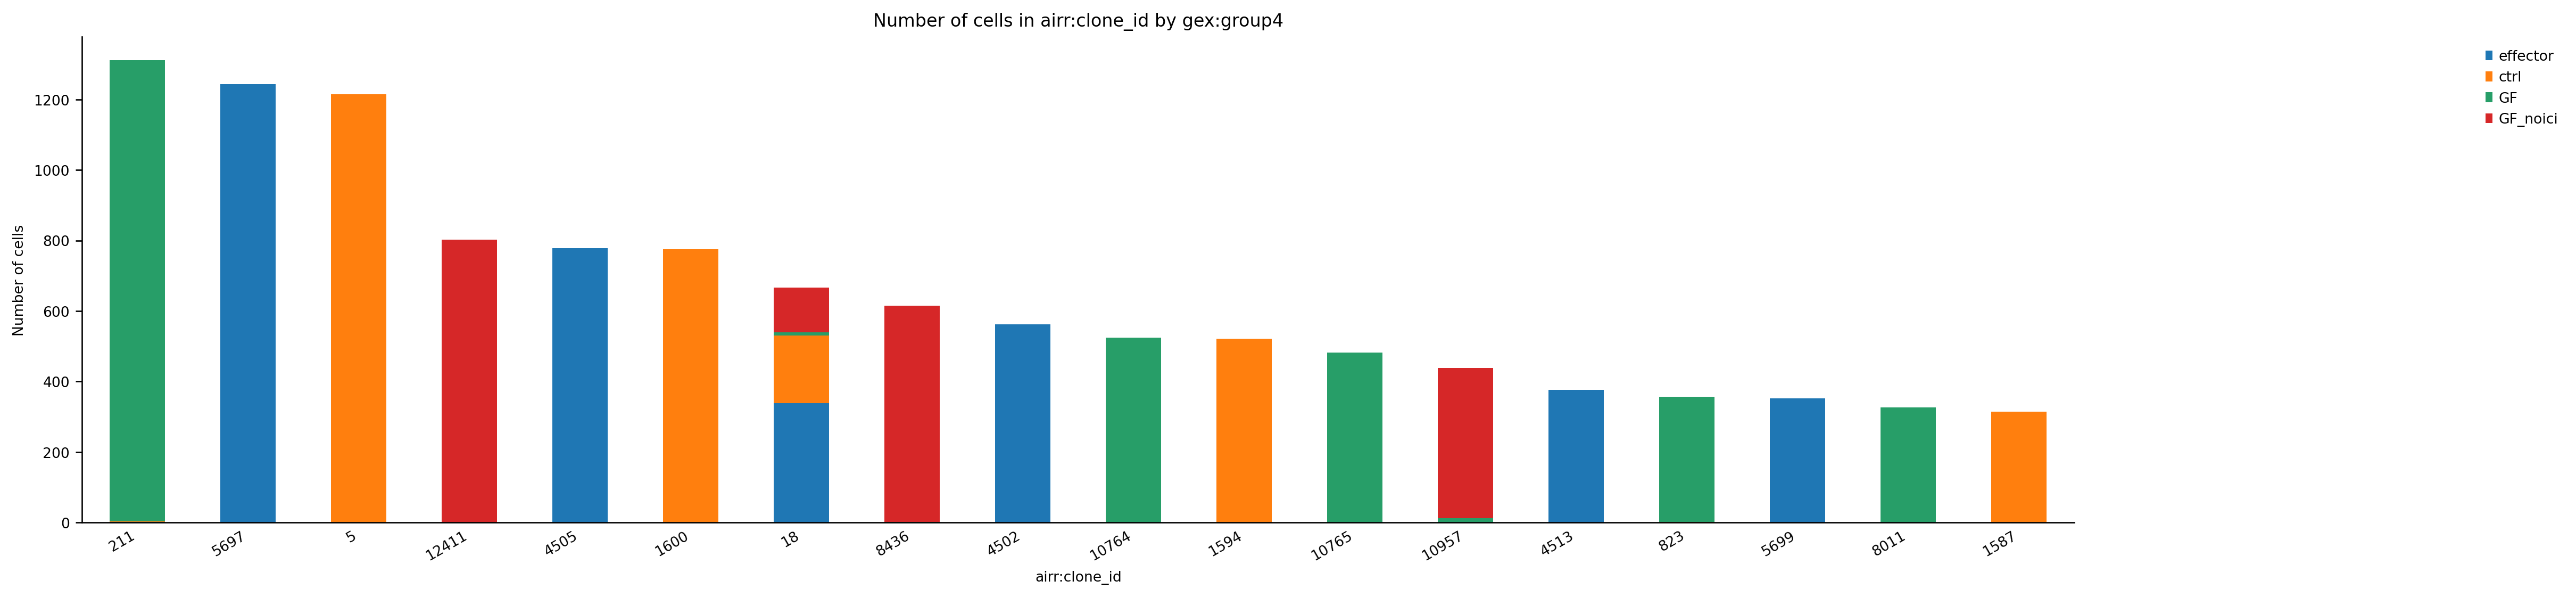

In [26]:
ir.pl.group_abundance(
    mdata_large,
    groupby="airr:clone_id",
    target_col="gex:group4",
    figsize=(20, 5)
)

## 5. Iggytop analysis DB

In [27]:
help(ir.datasets.iggytop)

Help on function iggytop in module scirpy.datasets:

iggytop(*, deduplicated: bool = True, tag: str = 'latest') -> anndata._core.anndata.AnnData
    Return the `IggyTop <https://iggytop.readthedocs.io/en/latest/>`_ database as an AnnData object.

    IggyTop (Immunological Graph Yielding Top receptor-epitope pairings)
    is a harmonized database of immunoreceptor-epitope pairings integrating data from
    multiple sources: IEDB, VDJdb, McPAS-TCR, CEDAR, ITRAP, TRAIT, TCR3d, and NeoTCR.
    V(D)J genes are normalized to IMGT standards and CDR3 sequences are harmonized following
    `AIRR standards <https://docs.airr-community.org/en/stable/datarep/rearrangements.html>`_.
    Pre-built datasets are released bimonthly.

    By default, a deduplicated version of the dataset is returned. Use this version if you'd like
    to work with the integrated resource combining data from all source datasets. If you prefer to work
    with a single resource, set `deduplicated=False` and filter the re

In [28]:
iggytop_tag = "data-2026.05.05.110331"
iggytop = ir.datasets.iggytop(tag=iggytop_tag)

In [29]:
iggytop.obs["source"].value_counts()

source
IEDB                             120667
CEDAR|IEDB                        74550
VDJDB                             66250
TRAIT|VDJDB                       25989
MCPAS                              9480
ITRAP                              5765
CEDAR|IEDB|MCPAS                   4918
TRAIT                              2806
CEDAR|IEDB|VDJDB                   1811
CEDAR|IEDB|TRAIT|VDJDB              614
NEOTCR                              514
IEDB|MCPAS                          337
TCR3D                               333
IEDB|TRAIT|VDJDB                    302
NEOTCR|TRAIT|VDJDB                  241
IEDB|VDJDB                          158
MCPAS|VDJDB                          73
CEDAR|IEDB|TRAIT                     60
CEDAR|IEDB|NEOTCR                    53
CEDAR|IEDB|NEOTCR|TRAIT|VDJDB        49
IEDB|TRAIT                           22
CEDAR|IEDB|ITRAP                     16
IEDB|ITRAP                           12
NEOTCR|VDJDB                          9
NEOTCR|TRAIT                     

In [30]:
ir.pp.ir_dist(mdata, iggytop, metric="identity", sequence="aa")

Computing sequence x sequence distance matrix for VJ sequences.
Computing sequence x sequence distance matrix for VDJ sequences.


In [31]:
ir.tl.ir_query(
    mdata,
    iggytop,
    metric="identity",
    sequence="aa",
    receptor_arms="any",
    dual_ir="any",
)

Initializing lookup tables. 
Computing clonotype x clonotype distances.
Stored IR distance matrix in `adata.uns["ir_query_iggytop_deduplicated_aa_identity"]`.


In [32]:
ir.tl.ir_query_annotate_df(
    mdata,
    iggytop,
    metric="identity",
    sequence="aa",
    include_ref_cols=["antigen_species", "antigen_name"],
)

,antigen_species,antigen_name
10mix-ICI1_AAACCTGAGAGCCTAG-1,Influenza A virus,PA
10mix-ICI1_AAACCTGAGAGCCTAG-1,Homo sapiens,INS
10mix-ICI1_AAACCTGAGAGCCTAG-1,Homo sapiens,INS
10mix-ICI1_AAACCTGAGAGCCTAG-1,Influenza,PA
10mix-ICI1_AAACCTGAGGGCACTA-1,Influenza A virus,NP
...,...,...
GF-ICI2_TTTGTCATCGTATCAG-1,Plasmodium berghei,GAP50
GF-ICI2_TTTGTCATCGTATCAG-1,Plasmodium berghei ANKA,acid phosphatase
GF-ICI2_TTTGTCATCGTATCAG-1,Plasmodium berghei ANKA,acid phosphatase
GF-ICI2_TTTGTCATCGTATCAG-1,Plasmodium berghei ANKA,acid phosphatase


In [33]:
ir.tl.ir_query_annotate(
    mdata,
    iggytop,
    metric="identity",
    sequence="aa",
    include_ref_cols=["antigen_species"],
    strategy="most-frequent",
)

100%|██████████| 13441/13441 [00:00<00:00, 23416.16it/s]

Stored result in `mdata.obs["airr:antigen_species"]`.


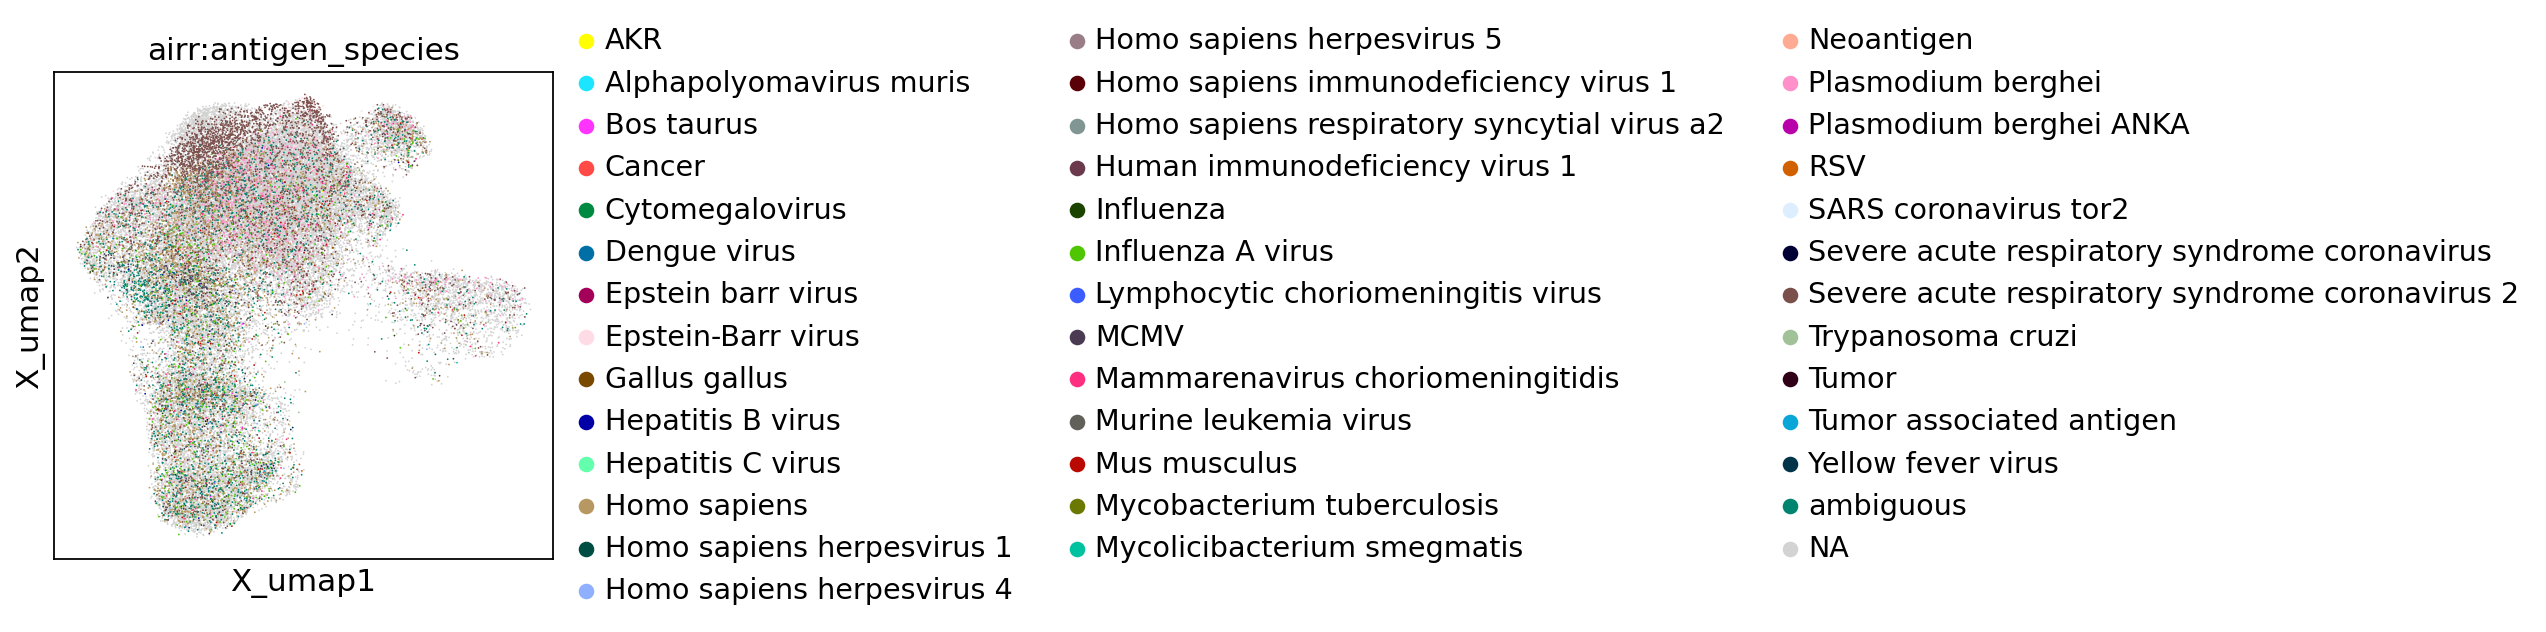

In [34]:
mu.pl.embedding(mdata, "gex:umap", color="airr:antigen_species")

In [35]:
ir.pp.ir_dist(
    mdata,
    metric="tcrdist",
    sequence="aa",
    cutoff=15,
)

Computing sequence x sequence distance matrix for VJ sequences.


/home/kvalem/.conda/envs/iggytop_env/lib/python3.12/site-packages/scirpy/ir_dist/metrics.py:1356: NumbaTypeSafetyWarning: unsafe cast from uint64 to int64. Precision may be lost.
  data_rows[row_index][0] = data_row_matrix[thread_id, 0:row_end_index].copy()


Computing sequence x sequence distance matrix for VDJ sequences.


## Table for every expanded clonotype

In [63]:
import pandas as pd
import numpy as np

# -----------------------------
# 1. Choose metadata columns
# -----------------------------

obs = mdata.obs.copy()

# Adjust these names if yours are different
clonotype_col = "airr:clone_id"
sample_col = "gex:sample_id"
condition_col = "gex:group4"
cluster_col = "gex:cell_annotation_05"

# IggyTop annotation columns
antigen_col = "airr:antigen_species"
antigen_name_col = "airr:antigen_name"


# Effector genes expected in mdata["gex"]
genes = ["Ifng", "Gzmb", "Prf1", "Nkg7", "Pdcd1", "Tox", "Cxcl13"]
genes = [g for g in genes if g in mdata["gex"].var_names]

# -----------------------------
# 2. Add gene expression to obs
# -----------------------------

expr = mdata["gex"][:, genes].to_df()
expr.columns = [f"{g}_expr" for g in genes]

obs = obs.join(expr)

# -----------------------------
# 3. Keep cells with clonotype info
# -----------------------------

obs_tcr = obs[
    obs[clonotype_col].notna()
].copy()

# -----------------------------
# 4. Per-clonotype summary
# -----------------------------

summary = (
    obs_tcr
    .groupby(clonotype_col)
    .agg(
        n_cells=(clonotype_col, "size"),
        n_samples=(sample_col, "nunique"),
        samples=(sample_col, lambda x: ",".join(sorted(x.astype(str).unique()))),
        conditions=(condition_col, lambda x: ",".join(sorted(x.astype(str).unique()))),
        major_cluster=(cluster_col, lambda x: x.value_counts().index[0]),
        antigen_species=(antigen_col, lambda x: ",".join(sorted(x.dropna().astype(str).unique()))),
       
    )
    .reset_index()
)

# Add mean expression per clonotype
expr_summary = (
    obs_tcr
    .groupby(clonotype_col)[[f"{g}_expr" for g in genes]]
    .mean()
    .reset_index()
)

summary = summary.merge(expr_summary, on=clonotype_col, how="left")

# -----------------------------
# 5. Add condition-specific abundance
# -----------------------------

clone_condition_counts = (
    obs_tcr
    .groupby([clonotype_col, condition_col])
    .size()
    .unstack(fill_value=0)
)

clone_condition_freq = clone_condition_counts.div(
    clone_condition_counts.sum(axis=0),
    axis=1
)

clone_condition_freq.columns = [
    f"freq_{c}" for c in clone_condition_freq.columns
]

summary = summary.merge(
    clone_condition_freq.reset_index(),
    on=clonotype_col,
    how="left"
)

# -----------------------------
# 6. Define priority categories
# -----------------------------

relevant_antigens = [
    "Tumor",
    "Tumor associated antigen",
    "Neoantigen",
    "Cancer",
    "Mus musculus",
    "Murine leukemia virus",
    "Lymphocytic choriomeningitis virus",
]

summary["relevant_iggytop_annotation"] = summary["antigen_species"].apply(
    lambda x: any(a.lower() in str(x).lower() for a in relevant_antigens)
)



summary = summary.sort_values(
    ["n_cells"],
    ascending=False
)

# -----------------------------
# 8. Save table
# -----------------------------

#summary.to_csv("prioritized_TCR_clonotypes_iggytop.csv", index=False)

/tmp/ipykernel_2039774/499949963.py:48: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(clonotype_col)
/tmp/ipykernel_2039774/499949963.py:64: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(clonotype_col)[[f"{g}_expr" for g in genes]]
/tmp/ipykernel_2039774/499949963.py:77: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby([clonotype_col, condition_col])


In [64]:
summary.head()

,airr:clone_id,n_cells,n_samples,samples,conditions,major_cluster,antigen_species,Ifng_expr,Gzmb_expr,Prf1_expr,Nkg7_expr,Pdcd1_expr,Tox_expr,Cxcl13_expr,freq_effector,freq_ctrl,freq_GF,freq_GF_noici,relevant_iggytop_annotation
211,211,1312,3,"GF1,ctrl1,effector1","GF,ctrl,effector",Activated,Homo sapiens,0.312985,1.000768,0.458403,3.109767,1.919580,1.033996,0.0,0.000150,0.000152,0.108055,0.000000,False
5697,5697,1244,1,effector2,effector,Activated,,0.275632,0.875972,0.390441,2.892362,1.673489,0.935748,0.0,0.093260,0.000000,0.000000,0.000000,False
5,5,1215,1,ctrl1,ctrl,Activated,Plasmodium berghei,0.339464,1.627998,0.628270,3.130137,2.060245,1.045527,0.0,0.000000,0.092550,0.000000,0.000000,False
12411,12411,802,1,GF_noICI2,GF_noici,Activated,,0.434948,1.566845,0.610754,3.094858,2.104173,0.514025,0.0,0.000000,0.000000,0.000000,0.083066,False
4505,4505,778,1,effector1,effector,Activated,,0.358023,0.856597,0.465439,2.765800,1.657951,0.920551,0.0,0.058325,0.000000,0.000000,0.000000,False


## Filter table to keep the clones that have more than 300 cells 

In [65]:
summary_filtered = summary[
    summary["airr:clone_id"].isin(keep_clones)
].copy()

In [66]:
summary_filtered

,airr:clone_id,n_cells,n_samples,samples,conditions,major_cluster,antigen_species,Ifng_expr,Gzmb_expr,Prf1_expr,Nkg7_expr,Pdcd1_expr,Tox_expr,Cxcl13_expr,freq_effector,freq_ctrl,freq_GF,freq_GF_noici,relevant_iggytop_annotation
211,211,1312,3,"GF1,ctrl1,effector1","GF,ctrl,effector",Activated,Homo sapiens,0.312985,1.000768,0.458403,3.109767,1.919580,1.033996,0.000000,0.000150,0.000152,0.108055,0.000000,False
5697,5697,1244,1,effector2,effector,Activated,,0.275632,0.875972,0.390441,2.892362,1.673489,0.935748,0.000000,0.093260,0.000000,0.000000,0.000000,False
5,5,1215,1,ctrl1,ctrl,Activated,Plasmodium berghei,0.339464,1.627998,0.628270,3.130137,2.060245,1.045527,0.000000,0.000000,0.092550,0.000000,0.000000,False
12411,12411,802,1,GF_noICI2,GF_noici,Activated,,0.434948,1.566845,0.610754,3.094858,2.104173,0.514025,0.000000,0.000000,0.000000,0.000000,0.083066,False
4505,4505,778,1,effector1,effector,Activated,,0.358023,0.856597,0.465439,2.765800,1.657951,0.920551,0.000000,0.058325,0.000000,0.000000,0.000000,False
1600,1600,775,1,ctrl2,ctrl,Activated,,0.363614,1.116049,0.366071,3.053190,1.560836,0.865363,0.000000,0.000000,0.059034,0.000000,0.000000,False
18,18,667,7,"GF2,GF_noICI1,GF_noICI2,ctrl1,ctrl2,effector1,...","GF,GF_noici,ctrl,effector",Activated,Severe acute respiratory syndrome coronavirus 2,0.387678,1.569787,0.386768,3.122251,2.114371,0.690899,0.000000,0.025339,0.014625,0.000743,0.013257,False
8436,8436,615,2,"GF1,GF_noICI1","GF,GF_noici",Activated,,0.259583,1.597502,0.413363,3.018039,1.966014,0.829397,0.000000,0.000000,0.000000,0.000165,0.063490,False
4502,4502,563,1,effector1,effector,Activated,,0.358029,0.784645,0.458799,2.957010,1.466832,1.036665,0.000000,0.042207,0.000000,0.000000,0.000000,False
10764,10764,524,1,GF2,GF,Activated,Severe acute respiratory syndrome coronavirus 2,0.313253,1.252834,0.313632,2.936630,1.907995,0.671606,0.000000,0.000000,0.000000,0.043288,0.000000,False


## 1. Clonotypes expanded specifically in effector + ICI mice

In [67]:
summary_filtered = summary[
    summary["conditions"].isin(["effector"])
].copy()

In [68]:
summary_filtered.antigen_species.unique()

array(['', 'Severe acute respiratory syndrome coronavirus 2',
       'Homo sapiens',
       'Homo sapiens,Severe acute respiratory syndrome coronavirus 2',
       'ambiguous', 'MCMV', 'Epstein-Barr virus', 'Plasmodium berghei',
       'Homo sapiens,ambiguous', 'Influenza A virus', 'Mus musculus',
       'Cytomegalovirus', 'Hepatitis B virus', 'Gallus gallus',
       'Tumor associated antigen', 'Trypanosoma cruzi',
       'Mammarenavirus choriomeningitidis', 'Mycobacterium tuberculosis',
       'Neoantigen', 'Human immunodeficiency virus 1',
       'Homo sapiens herpesvirus 4',
       'Homo sapiens immunodeficiency virus 1', 'Murine leukemia virus',
       'Mycolicibacterium smegmatis', 'Epstein barr virus', 'Influenza',
       'Plasmodium berghei ANKA', 'Lymphocytic choriomeningitis virus'],
      dtype=object)

In [69]:
summary_filtered = summary_filtered[
    summary_filtered["antigen_species"].isin(["Neoantigen","Mus musculus"])]

In [70]:
summary_filtered

,airr:clone_id,n_cells,n_samples,samples,conditions,major_cluster,antigen_species,Ifng_expr,Gzmb_expr,Prf1_expr,Nkg7_expr,Pdcd1_expr,Tox_expr,Cxcl13_expr,freq_effector,freq_ctrl,freq_GF,freq_GF_noici,relevant_iggytop_annotation
4523,4523,18,1,effector1,effector,Activated,Mus musculus,0.482592,0.958155,0.376746,2.881541,2.163472,0.691781,0.0,0.001349,0.0,0.0,0.0,True
4674,4674,3,1,effector1,effector,Activated,Mus musculus,0.258905,1.020384,0.111117,1.508209,0.878430,0.194308,0.0,0.000225,0.0,0.0,0.0,True
4760,4760,3,1,effector1,effector,Effector_memory,Mus musculus,0.284033,1.621407,0.304813,3.216677,2.622682,0.000000,0.0,0.000225,0.0,0.0,0.0,True
7860,7860,1,1,effector2,effector,Activated,Mus musculus,0.000000,0.820535,0.000000,2.999511,2.155278,0.000000,0.0,0.000075,0.0,0.0,0.0,True
7732,7732,1,1,effector2,effector,Effector_memory,Mus musculus,0.887822,2.259572,0.000000,2.398696,1.350580,0.000000,0.0,0.000075,0.0,0.0,0.0,True
7796,7796,1,1,effector2,effector,Stem/Resident_memory,Neoantigen,0.000000,1.101106,0.000000,1.389099,0.000000,0.000000,0.0,0.000075,0.0,0.0,0.0,True
6537,6537,1,1,effector2,effector,Effector_memory,Mus musculus,0.000000,2.211072,0.000000,2.515734,0.000000,0.000000,0.0,0.000075,0.0,0.0,0.0,True
5915,5915,1,1,effector2,effector,Cycling,Mus musculus,0.000000,1.334202,0.000000,2.457819,0.000000,0.000000,0.0,0.000075,0.0,0.0,0.0,True
7298,7298,1,1,effector2,effector,Activated,Mus musculus,0.605387,0.605387,0.000000,1.640899,1.790386,0.000000,0.0,0.000075,0.0,0.0,0.0,True
7575,7575,1,1,effector2,effector,Stem/Resident_memory,Mus musculus,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000075,0.0,0.0,0.0,True


They correspond to clonotypes with little cells

## 2. Clonotypes found in activated/exhausted CD8 populations

In [71]:
summary_filtered = summary[
    summary["major_cluster"].isin(["Activated","Effector_memory","Stem/Resident_memory"])
].copy()

In [72]:
#summary_filtered.head(30)

In [73]:
#summary_filtered.antigen_species.unique()

## 3. Clonotypes annotated as mouse-derived

In [74]:
summary_filtered = summary[
    summary["antigen_species"].isin(["Mus musculus"])
].copy()

In [75]:
#summary_filtered.head(30)

## 4. Tumor / Neoantigen annotations

In [76]:
summary_filtered = summary[
    summary["antigen_species"].isin(["Neoantigen","Cancer"])
].copy()

In [77]:
summary_filtered.head(30)

,airr:clone_id,n_cells,n_samples,samples,conditions,major_cluster,antigen_species,Ifng_expr,Gzmb_expr,Prf1_expr,Nkg7_expr,Pdcd1_expr,Tox_expr,Cxcl13_expr,freq_effector,freq_ctrl,freq_GF,freq_GF_noici,relevant_iggytop_annotation
7796,7796,1,1,effector2,effector,Stem/Resident_memory,Neoantigen,0.000000,1.101106,0.0,1.389099,0.000000,0.0,0.0,0.000075,0.000000,0.0,0.000000,True
13245,13245,1,1,GF_noICI2,GF_noici,Stem/Resident_memory,Neoantigen,0.894148,0.543850,0.0,1.801443,0.543850,0.0,0.0,0.000000,0.000000,0.0,0.000104,True
1143,1143,1,1,ctrl1,ctrl,Stem/Resident_memory,Cancer,0.000000,0.000000,0.0,1.837387,0.720773,0.0,0.0,0.000000,0.000076,0.0,0.000000,True


## 5. Shared clonotypes across multiple mice

## Explore specific clonotypes

In [78]:
ir.pp.ir_dist(
    mdata,
    metric="tcrdist",
    sequence="aa",
    cutoff=15,
)

Computing sequence x sequence distance matrix for VJ sequences.
Computing sequence x sequence distance matrix for VDJ sequences.


In [79]:
ir.tl.define_clonotype_clusters(mdata, sequence="aa", metric="tcrdist", receptor_arms="all", dual_ir="any")

Initializing lookup tables. 
Computing clonotype x clonotype distances.
Stored result in `mdata.obs["airr:cc_aa_tcrdist"]`.
Stored result in `mdata.obs["airr:cc_aa_tcrdist_size"]`.


In [80]:
ir.tl.clonotype_network(mdata, min_cells=500, sequence="aa", metric="tcrdist")

### 7796 - related to species neoantigen

In [81]:
with ir.get.airr_context(mdata, "junction_aa", ["VJ_1", "VDJ_1", "VJ_2", "VDJ_2"]):
    cdr3_ct_7796 = (
        # TODO astype(str) is required due to a bug in pandas ignoring `dropna=False`. It seems fixed in pandas 2.x
        mdata.obs.loc[lambda x: x["airr:cc_aa_tcrdist"] == "7796"]
        .astype(str)
        .groupby(
            [
                "VJ_1_junction_aa",
                "VDJ_1_junction_aa",
                "VJ_2_junction_aa",
                "VDJ_2_junction_aa",
                "airr:receptor_subtype",
            ],
            observed=True,
            dropna=False,
        )
        .size()
        .reset_index(name="n_cells")
    )
cdr3_ct_7796

,VJ_1_junction_aa,VDJ_1_junction_aa,VJ_2_junction_aa,VDJ_2_junction_aa,airr:receptor_subtype,n_cells
0,CAVRDTNAYKVIF,CASSFDNANTEVFF,NaN,NaN,TRA+TRB,1


### 5967 - in effector 

In [82]:
with ir.get.airr_context(mdata, "junction_aa", ["VJ_1", "VDJ_1", "VJ_2", "VDJ_2"]):
    cdr3_ct_5967 = (
        # TODO astype(str) is required due to a bug in pandas ignoring `dropna=False`. It seems fixed in pandas 2.x
        mdata.obs.loc[lambda x: x["airr:cc_aa_tcrdist"] == "5967"]
        .astype(str)
        .groupby(
            [
                "VJ_1_junction_aa",
                "VDJ_1_junction_aa",
                "VJ_2_junction_aa",
                "VDJ_2_junction_aa",
                "airr:receptor_subtype",
            ],
            observed=True,
            dropna=False,
        )
        .size()
        .reset_index(name="n_cells")
    )
cdr3_ct_5967

,VJ_1_junction_aa,VDJ_1_junction_aa,VJ_2_junction_aa,VDJ_2_junction_aa,airr:receptor_subtype,n_cells
0,CALRHYGSSGNKLIF,CASRRLGYEQYF,NaN,NaN,TRA+TRB,1


### 18 - clonotype shared

In [83]:
with ir.get.airr_context(mdata, "junction_aa", ["VJ_1", "VDJ_1", "VJ_2", "VDJ_2"]):
    cdr3_ct_18 = (
        # TODO astype(str) is required due to a bug in pandas ignoring `dropna=False`. It seems fixed in pandas 2.x
        mdata.obs.loc[lambda x: x["airr:cc_aa_tcrdist"] == "18"]
        .astype(str)
        .groupby(
            [
                "VJ_1_junction_aa",
                "VDJ_1_junction_aa",
                "VJ_2_junction_aa",
                "VDJ_2_junction_aa",
                "airr:receptor_subtype",
            ],
            observed=True,
            dropna=False,
        )
        .size()
        .reset_index(name="n_cells")
    )
cdr3_ct_18

,VJ_1_junction_aa,VDJ_1_junction_aa,VJ_2_junction_aa,VDJ_2_junction_aa,airr:receptor_subtype,n_cells
0,CAALYNQGKLIF,CASGDAGTGNYAEQFF,CAMRATSSGQKLVF,NaN,TRA+TRB,1
1,CAASASYGNEKITF,CASSQDWAGGAREQYF,NaN,NaN,TRA+TRB,4
2,CALGNNYAQGLTF,CASGGWEQYF,CAMRATSSGQKLVF,NaN,TRA+TRB,1
3,CALSATSNAYKVIF,CASGGWEQYF,NaN,CASGARDRGLFF,TRA+TRB,1
4,CALSATSNAYKVIF,CASGGWEQYF,NaN,NaN,TRA+TRB,614
5,CALSVMSNCNVLYF,CASGGYEQYF,NaN,NaN,TRA+TRB,1
6,CALSVMSNYNVLYF,CASGGYEQYF,CALGMSNYNVLYF,NaN,TRA+TRB,1
7,CALSVMSNYNVLYF,CASGGYEQYF,CALSATSNAYKVIF,NaN,TRA+TRB,2
8,CALSVMSNYNVLYF,CASGGYEQYF,CAMRATSSGQKLVF,NaN,TRA+TRB,1
9,CALSVMSNYNVLYF,CASGGYEQYF,CASVEGADRLTF,CASSLGQKISNERLFF,TRA+TRB,1


In [84]:
summary_filtered = summary[
    summary["samples"].isin(["effector1","efector2"])
].copy()

In [85]:
#summary_filtered.head(30)

In [86]:
summary_filtered = summary[
    summary["samples"].apply(
        lambda x: (
            "effector1" in str(x).split(",")
            and "effector2" in str(x).split(",")
        )
    )
].copy()

In [87]:
summary_filtered.head()

,airr:clone_id,n_cells,n_samples,samples,conditions,major_cluster,antigen_species,Ifng_expr,Gzmb_expr,Prf1_expr,Nkg7_expr,Pdcd1_expr,Tox_expr,Cxcl13_expr,freq_effector,freq_ctrl,freq_GF,freq_GF_noici,relevant_iggytop_annotation
18,18,667,7,"GF2,GF_noICI1,GF_noICI2,ctrl1,ctrl2,effector1,...","GF,GF_noici,ctrl,effector",Activated,Severe acute respiratory syndrome coronavirus 2,0.387678,1.569787,0.386768,3.122251,2.114371,0.690899,0.0,0.025339,0.014625,0.000743,0.013257,False


## Conclusion

- The clonotypes that are present in more than 300 cells they do not correspond to any of the species of interest ( Mus musculus, Neoantigen, Cancer)
- The clonotypes present only in effector they are present in very few cells (max 18) 
- The clonotypes present in Mus musculus species they are present in very few cells (max 18) 
- The clonotypes present inTumor / Neoantigen antigen_species they are present in very few cells (max 1)
- The clonotypes present in effector1 and effector2 samples is just number 18. Which is shared across all samples.

In [88]:
mdata

MuData object with n_obs × n_vars = 48227 × 17590
  3 modalities
    gex:	48227 × 17581
      obs:	'adata_name', 'condition', 'batch_id', 'sample_id', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mito', 'log1p_total_counts_mito', 'pct_counts_mito', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'rna_leiden', 'rna_leiden_05', 'gex03', 'group4', 'cell_annotation_05'
      var:	'gene_ids', 'feature_types', 'mito', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection', 'n_cells'
      uns:	'cell_annotation_05_colors', 'gex03', 'gex03_colors', 'group4_colors', 'hvg', 'log1p', 'neighbors', 'pca', 'rna_leiden', 'rna_leiden_05', 'rna_leiden_05_colors', 'rna_leiden_colors', 'sample_id_colors', 'umap', 'airr:antigen_species_colors'
      obsm:	'X_pca', 'X_umap'
      varm:	'PCs'
      layers:	'counts'
      obsp:	'connectivities', 'distances'
    adt:	48227 × 9
      obs:	'sample_id', 'year', 'tissue', 'treatment', 'received_ici'
    airr:	48227 × 0
      obs:	'sample_id', 'group4', 'receptor_type', 'receptor_subtype', 'chain_pairing', 'clone_id', 'clone_id_size', 'antigen_species', 'cc_aa_tcrdist', 'cc_aa_tcrdist_size'
      uns:	'chain_indices', 'ir_dist_nt_identity', 'clone_id', 'clonotype_network', 'ir_dist_iggytop_deduplicated_aa_identity', 'ir_query_iggytop_deduplicated_aa_identity', 'ir_dist_aa_tcrdist', 'cc_aa_tcrdist'
      obsm:	'airr', 'chain_indices', 'X_clonotype_network'

## Creating a file to have all the VDJ sequences from the top clones with > 300 cells 

In [90]:
import pandas as pd
import scirpy as ir

mdata_clonotype_col = "airr:cc_aa_tcrdist"
keep_clones_str = [str(x) for x in keep_clones]

# -----------------------------
# 1. Make sure summary has clonotype as a column
# -----------------------------

summary2 = summary.copy()

if "airr:cc_aa_tcrdist" in summary2.columns:
    summary_clonotype_col = "airr:cc_aa_tcrdist"

elif "cc_aa_tcrdist" in summary2.columns:
    summary_clonotype_col = "cc_aa_tcrdist"

else:
    summary2 = summary2.reset_index()
    print(summary2.columns)
    
    # after reset_index, use the first column as clonotype column
    summary_clonotype_col = summary2.columns[0]

print("Using summary clonotype column:", summary_clonotype_col)

# -----------------------------
# 2. Extract CDR3 sequences for keep_clones
# -----------------------------

with ir.get.airr_context(
    mdata,
    "junction_aa",
    ["VJ_1", "VDJ_1", "VJ_2", "VDJ_2"]
):
    cdr3_keep_clones = (
        mdata.obs
        .loc[lambda x: x[mdata_clonotype_col].astype(str).isin(keep_clones_str)]
        .astype(str)
        .groupby(
            [
                mdata_clonotype_col,
                "VJ_1_junction_aa",
                "VDJ_1_junction_aa",
                "VJ_2_junction_aa",
                "VDJ_2_junction_aa",
                "airr:receptor_subtype",
            ],
            observed=True,
            dropna=False,
        )
        .size()
        .reset_index(name="n_cells_cdr3")
    )

cdr3_keep_clones = cdr3_keep_clones.rename(
    columns={mdata_clonotype_col: summary_clonotype_col}
)

# -----------------------------
# 3. Filter summary and merge
# -----------------------------

summary_keep_clones[summary_clonotype_col] = (
    summary_keep_clones[summary_clonotype_col].astype(str)
)

cdr3_keep_clones[summary_clonotype_col] = (
    cdr3_keep_clones[summary_clonotype_col].astype(str)
)

merged_keep_clones = summary_keep_clones.merge(
    cdr3_keep_clones,
    on=summary_clonotype_col,
    how="left"
)

merged_keep_clones.to_csv(
    "prioritized_keep_clones_with_cdr3_sequences.csv",
    index=False
)

merged_keep_clones.head()

Index(['index', 'airr:clone_id', 'n_cells', 'n_samples', 'samples',
       'conditions', 'major_cluster', 'antigen_species', 'Ifng_expr',
       'Gzmb_expr', 'Prf1_expr', 'Nkg7_expr', 'Pdcd1_expr', 'Tox_expr',
       'Cxcl13_expr', 'freq_effector', 'freq_ctrl', 'freq_GF', 'freq_GF_noici',
       'relevant_iggytop_annotation'],
      dtype='object')
Using summary clonotype column: index


,index,airr:clone_id,n_cells,n_samples,samples,conditions,major_cluster,antigen_species,Ifng_expr,Gzmb_expr,...,freq_ctrl,freq_GF,freq_GF_noici,relevant_iggytop_annotation,VJ_1_junction_aa,VDJ_1_junction_aa,VJ_2_junction_aa,VDJ_2_junction_aa,airr:receptor_subtype,n_cells_cdr3
0,211,211,1312,3,"GF1,ctrl1,effector1","GF,ctrl,effector",Activated,Homo sapiens,0.312985,1.000768,...,0.000152,0.108055,0.000000,False,CALSDRTGNTGKLIF,CASRPRQGAGNTLYF,NaN,NaN,TRA+TRB,1
1,5697,5697,1244,1,effector2,effector,Activated,,0.275632,0.875972,...,0.000000,0.000000,0.000000,False,CAARQGGRALIF,CASSDLRRGFSNERLFF,NaN,NaN,TRA+TRB,2
2,5,5,1215,1,ctrl1,ctrl,Activated,Plasmodium berghei,0.339464,1.627998,...,0.092550,0.000000,0.000000,False,CAASPITGNTGKLIF,CSSRHQNTLYF,NaN,NaN,TRA+TRB,1215
3,12411,12411,802,1,GF_noICI2,GF_noici,Activated,,0.434948,1.566845,...,0.000000,0.000000,0.083066,False,CAAAMDYANKMIF,CASSLGQNERLFF,NaN,NaN,TRA+TRB,1
4,4505,4505,778,1,effector1,effector,Activated,,0.358023,0.856597,...,0.000000,0.000000,0.000000,False,CAVSARPGTGSNRLTF,CASSQGAGNTLYF,NaN,NaN,TRA+TRB,1
